# Inspecting the fake market
We made 100 fake price charts (seeds 0 to 99) with `make_prices` from `market.py`. Here we look at them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from market import make_prices

N_CHARTS = 100
charts = [make_prices(seed=s) for s in range(N_CHARTS)]
print(len(charts), "charts, each with", len(charts[0]), "days")

100 charts, each with 1000 days


## All 100 charts
One small graph per chart. Every one is pure randomness, but look how different they feel: some 'trend', some 'crash', some 'recover'.

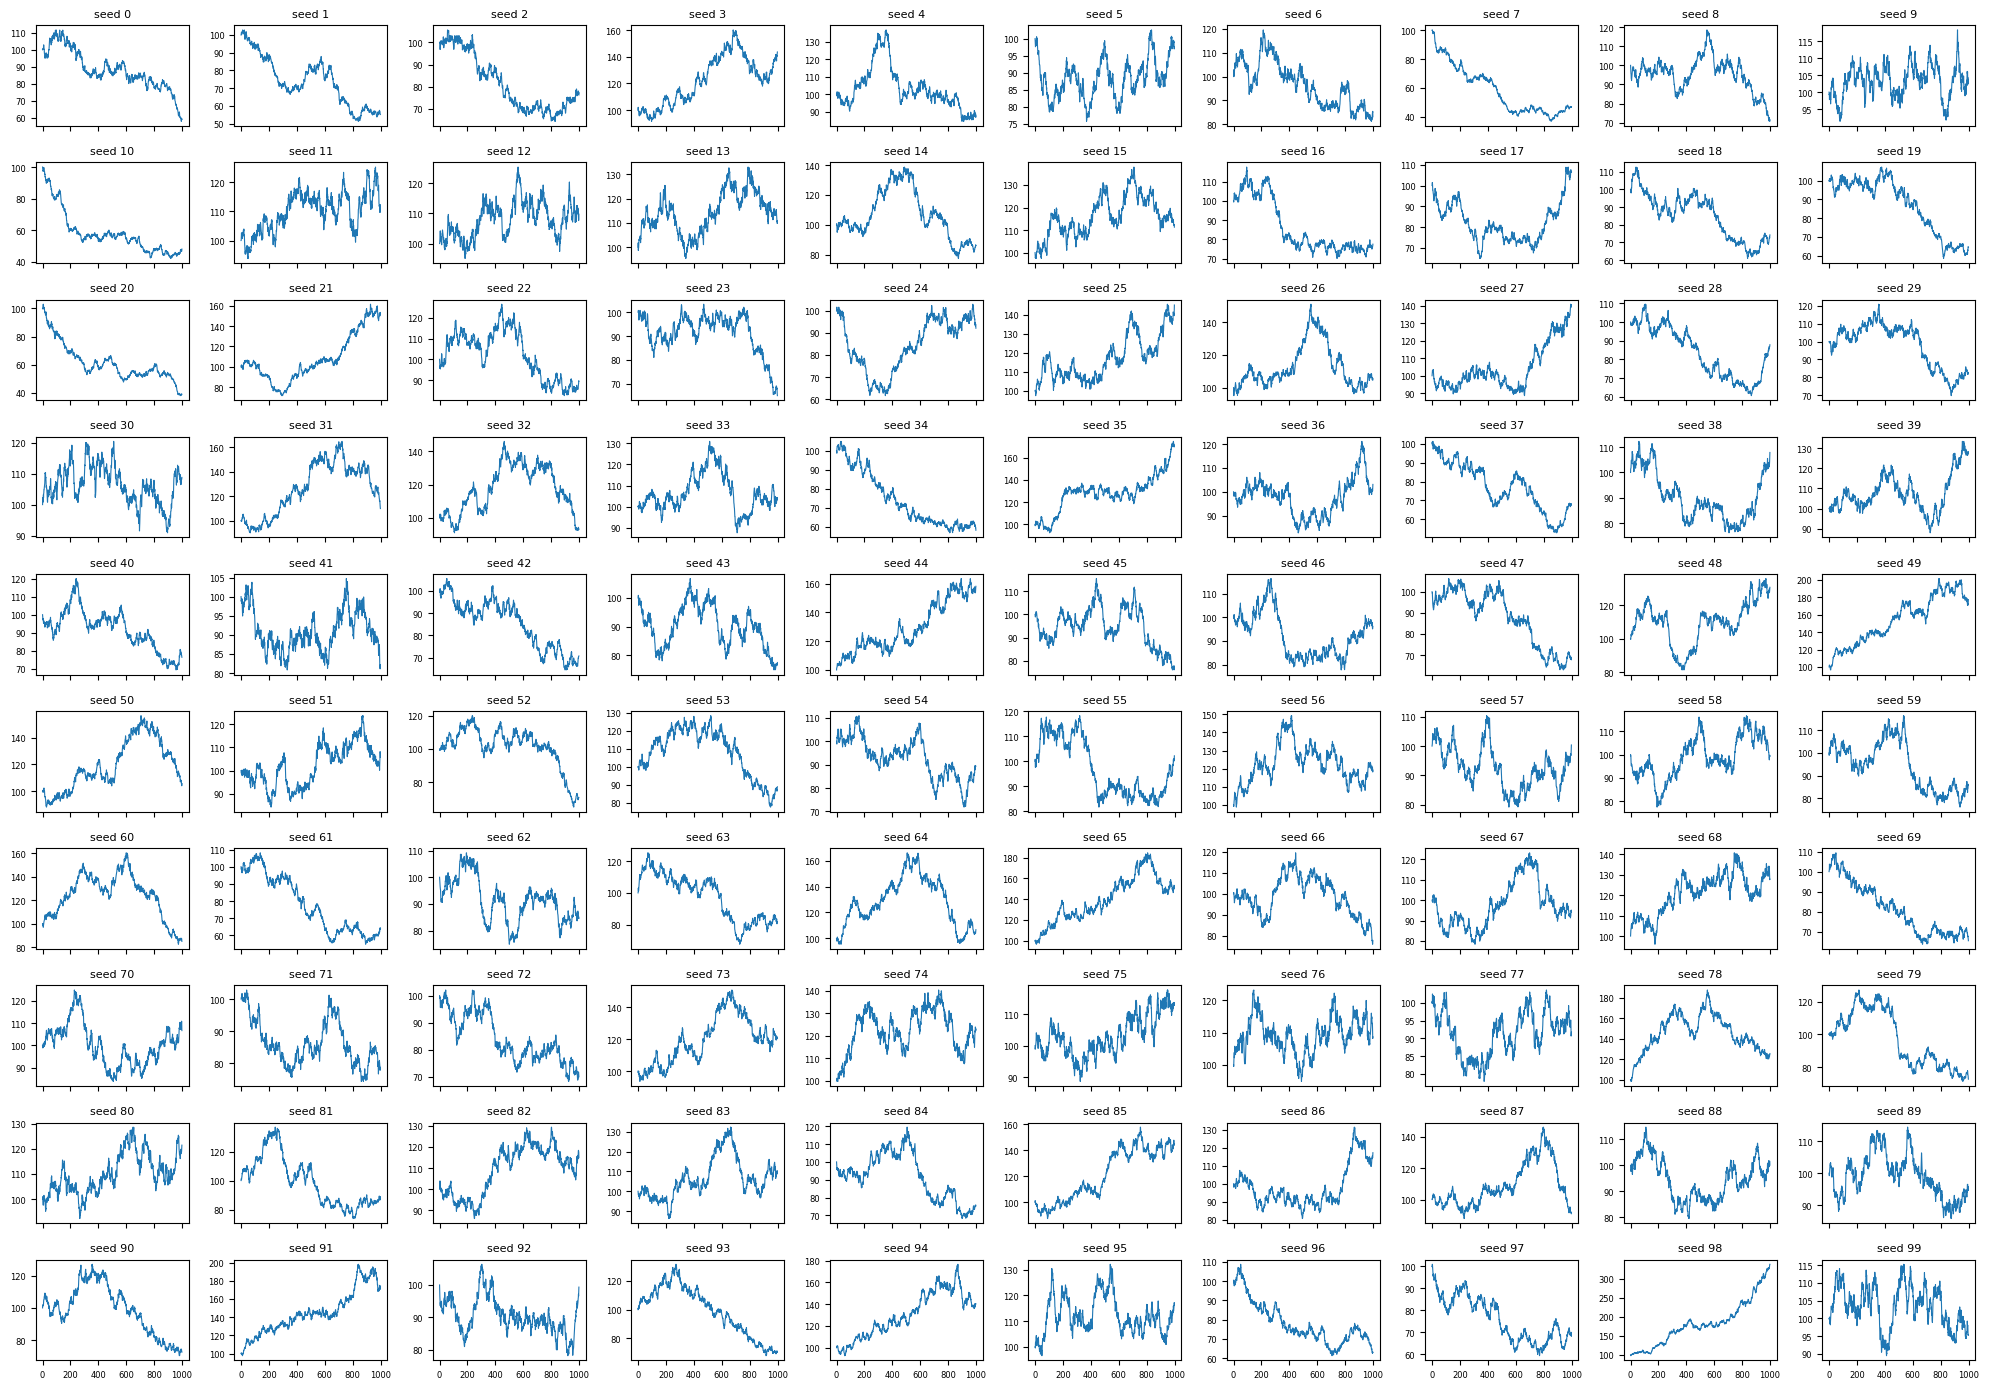

In [2]:
fig, axes = plt.subplots(10, 10, figsize=(20, 14), sharex=True)
for s, ax in enumerate(axes.flat):
    ax.plot(charts[s], linewidth=0.8)
    ax.set_title(f"seed {s}", fontsize=8)
    ax.tick_params(labelsize=6)
plt.tight_layout()
plt.show()

## How does the change happen? One chart up close
Top: the price. Middle: each day's % change. Bottom: how those daily changes are spread out. Change `SEED` to look at any chart.

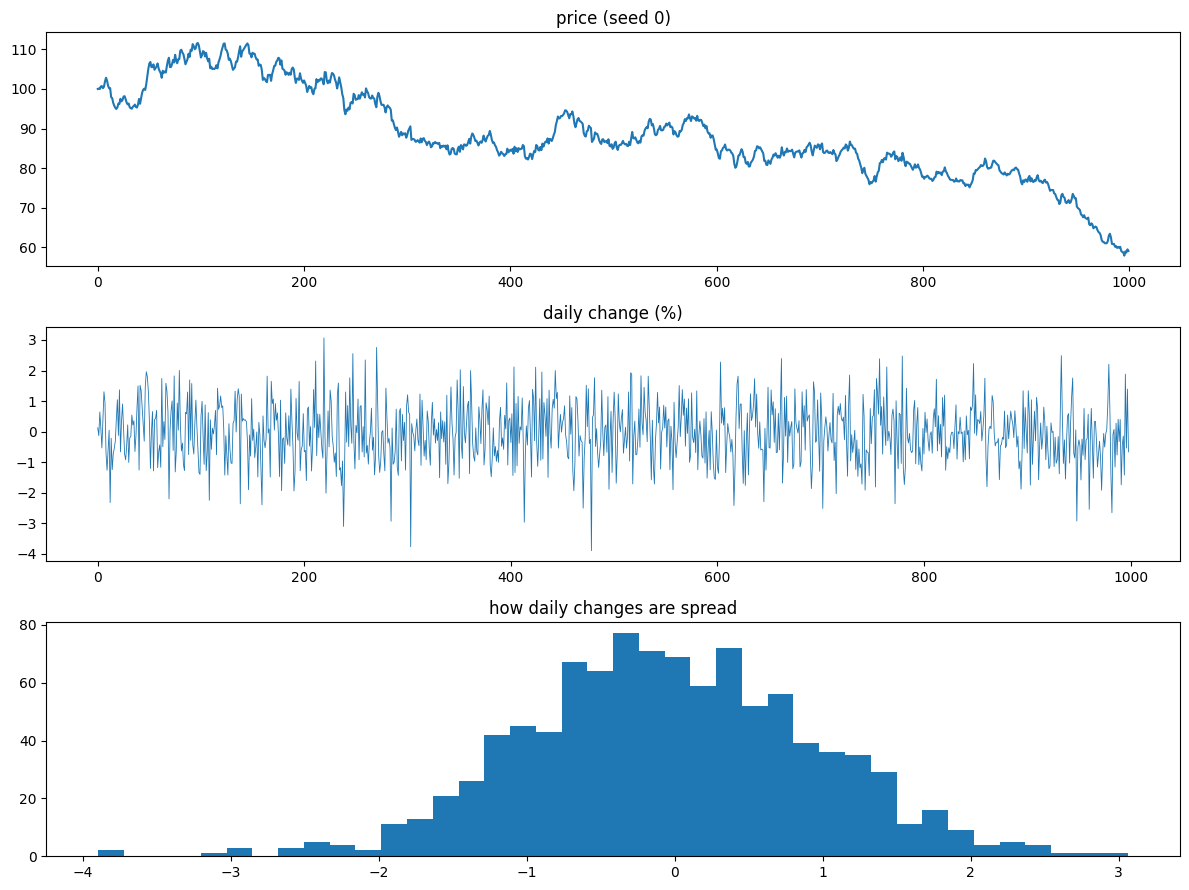

In [3]:
SEED = 0
p = charts[SEED]
daily = p[1:] / p[:-1] - 1

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].plot(p); axes[0].set_title(f"price (seed {SEED})")
axes[1].plot(daily * 100, linewidth=0.6); axes[1].set_title("daily change (%)")
axes[2].hist(daily * 100, bins=40); axes[2].set_title("how daily changes are spread")
plt.tight_layout(); plt.show()

## Numbers for all 100 charts
If the generator does what we think: average daily change near 0, typical size near 1%. Final price is all over the place anyway.

In [4]:
rows = []
for s, p in enumerate(charts):
    d = p[1:] / p[:-1] - 1
    rows.append({"seed": s, "final_price": p[-1], "min_price": p.min(), "max_price": p.max(),
                 "avg_daily_%": d.mean() * 100, "typical_size_%": d.std() * 100,
                 "total_return_%": (p[-1] / p[0] - 1) * 100})
df = pd.DataFrame(rows).set_index("seed")
df.describe().round(2)

,final_price,min_price,max_price,avg_daily_%,typical_size_%,total_return_%
count,100.00,100.00,100.00,100.00,100.00,100.00
mean,99.96,78.61,129.56,-0.00,0.99,-0.04
std,36.98,14.49,31.03,0.03,0.02,36.98
min,39.08,36.65,100.00,-0.09,0.94,-60.92
25%,77.15,69.06,109.52,-0.02,0.98,-22.85
50%,95.02,79.39,121.00,-0.00,0.99,-4.98
75%,111.54,90.94,138.13,0.02,1.01,11.54
max,337.49,100.00,337.49,0.13,1.05,237.49


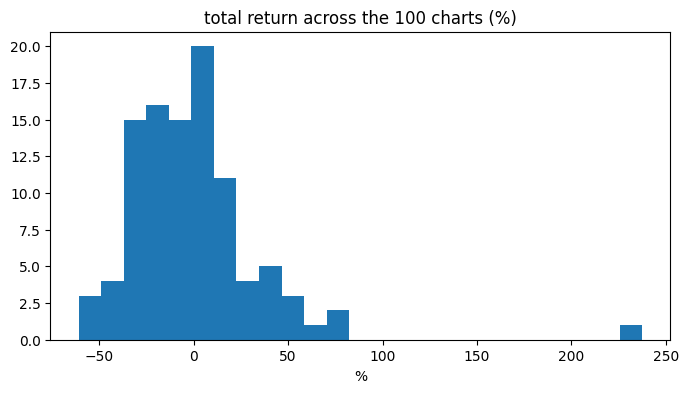

charts that ended higher: 45 out of 100


In [5]:
plt.figure(figsize=(8, 4))
plt.hist(df["total_return_%"], bins=25)
plt.title("total return across the 100 charts (%)")
plt.xlabel("%"); plt.show()
print("charts that ended higher:", (df["total_return_%"] > 0).sum(), "out of", N_CHARTS)